# **📋 RETAIL SALES ANALYSIS**

## **🎯 Project Objective:**
### **The project aims to extract meaningful insights from the sales dataset based on order date,age,gender,product details etc and helping business to take appropriate decisions based on findings.**

In [1]:
# Importing important libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing dataset:

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [3]:
# Data Inspection:

print(df.describe())
df.info()

# The data have too many inconsistency, so first the data cleaning process is performed.

               age     quantity    unit_price  discount_pct  sales_amount  \
count  4150.000000  4170.000000   4280.000000   4143.000000  4.280000e+03   
mean     35.335181     7.379856  10621.154428      0.202085  6.235864e+04   
std      35.709382    43.578352  17323.704016      0.118095  3.166998e+05   
min      -7.000000    -1.000000     50.260000      0.000000  3.945000e+01   
25%      26.000000     3.000000    672.222500      0.100000  2.462165e+03   
50%      34.000000     5.000000   2228.435000      0.210000  9.548075e+03   
75%      42.000000     8.000000  12717.435000      0.310000  5.006964e+04   
max     999.000000   999.000000  79957.920000      0.400000  1.736031e+07   

             profit  shipping_cost  customer_satisfaction  days_to_ship  
count  4.280000e+03    4280.000000            3932.000000   4180.000000  
mean   1.168713e+04      63.358836               3.016531      5.620335  
std    5.287522e+04      18.312281               1.413127      4.178663  
min    1.5

## **📌 Data Cleaning:**

In [4]:
# 1. Correcting negative values:
mask = (df['age'] < 0) | (df['quantity'] < 0) | (df['shipping_cost'] < 0) | (df['days_to_ship'] < 0)
mask.sum()
df = df[~mask]

mask2 = (df['age'] == 0) | (df['quantity'] == 0)
df = df[~mask2]

In [5]:
# 2.Fixing age:

print((df['age'] < 18).sum())   
df = df[df['age'] >= 18]
print(df.shape)

319
(3788, 21)


In [6]:
# Fixing unrealistic values:

print((df['age'] > 100).sum())        
print((df['quantity'] > 100).sum())    
print((df['days_to_ship'] > 30).sum())
df[df['age'] > 100]     # look at the actual rows


mask3 = (df['age'] > 100) | (df['quantity'] > 100) | (df['days_to_ship'] > 30)
print(mask3.sum(), "rows to drop")   # check total (could be less than 20 if some rows overlap)

df = df[~mask3]
print(df.shape)

8
7
5
19 rows to drop
(3769, 21)


In [7]:
df.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,3769.000000,3669.000000,3769.000000,3649.000000,3.769000e+03,3769.000000,3769.000000,3462.000000,3685.000000
mean,36.090475,5.533660,10530.296466,0.202269,5.523641e+04,10301.035009,63.397601,3.019064,5.506649
std,10.344416,2.908318,17201.283979,0.117753,1.146720e+05,17917.903753,18.363269,1.412654,2.863767
min,18.000000,1.000000,50.260000,0.000000,3.945000e+01,1.560000,0.510000,1.000000,0.000000
25%,28.000000,3.000000,663.740000,0.100000,2.474960e+03,703.910000,50.760000,2.000000,3.000000
50%,35.000000,6.000000,2218.420000,0.210000,9.475190e+03,3117.660000,63.390000,3.000000,6.000000
75%,43.000000,8.000000,12544.460000,0.310000,5.006636e+04,10394.780000,75.840000,4.000000,8.000000
max,72.000000,10.000000,79957.920000,0.400000,1.071676e+06,141319.320000,133.350000,5.000000,10.000000


In [8]:
# Handling missing values:

df['discount_pct'] = df['discount_pct'].fillna(0)
df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

In [9]:
# Data Type:

print(df.dtypes)

# Fixing date:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=False)
print(df["order_date"].dtype)

order_id                     str
order_date                   str
customer_id                  str
customer_name                str
age                      float64
gender                       str
region                       str
city                         str
product_category             str
product_name                 str
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method               str
customer_satisfaction    float64
return_flag               object
order_status                 str
days_to_ship             float64
dtype: object
datetime64[us]


In [10]:
# Data correcting:

# Gender:
print(df['gender'].unique())
print(df['gender'].value_counts())

df['gender'] = df['gender'].str.strip().str.upper()  # remove extra spaces, make uppercase

# correcting values:
df['gender'] = df['gender'].replace({
    'F': 'Female',
    'FEMALE': 'Female',
    'M': 'Male',
    'MALE': 'Male'})


# Order status:
print(df['order_status'].unique())
print(df['order_status'].value_counts())

df["order_status"] = df["order_status"].str.strip().str.upper()

# correcting values:
df["order_status"] = df["order_status"].replace({
    'delivered': 'Delivered',
    'cancelled': 'Cancelled',
    'shipped': 'Shipped',
    'pending': 'Pending'})

<StringArray>
[ 'Other',   'Male', 'Female',      'f',      'F',   'male', 'female',
   'MALE',      'm',      'M', 'FEMALE']
Length: 11, dtype: str
gender
Other     1259
Female    1061
Male      1060
male        59
f           53
F           52
MALE        50
m           48
female      44
FEMALE      42
M           41
Name: count, dtype: int64
<StringArray>
[ 'Returned', 'Delivered', 'Cancelled',   'Shipped', 'delivered',   'Pending',
 'cancelled',   'shipped',   'pending']
Length: 9, dtype: str
order_status
Delivered    2344
Returned      549
Cancelled     303
Shipped       280
Pending       155
delivered     105
shipped        15
cancelled      12
pending         6
Name: count, dtype: int64


## **📌 Exploratory Data Analysis**

## *Time Based Trend:*

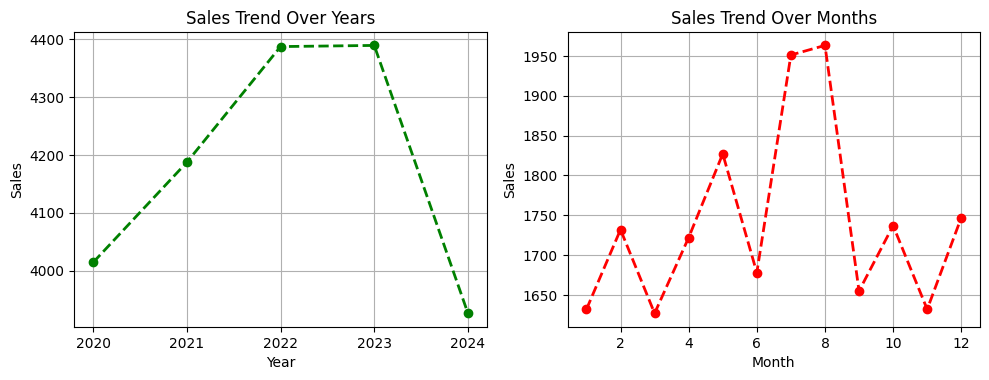

In [21]:
# Monthly & Yearly trend:
df["order_month"] = df["order_date"].dt.month
df["order_year"] = df["order_date"].dt.year

yearly_sales = df.groupby("order_year")["quantity"].sum()
monthly_sales = df.groupby("order_month")["quantity"].sum()

# Plotting on line chart
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
plt.plot(yearly_sales.index,yearly_sales.values,color='green',marker='o',linewidth=2,linestyle='--')
plt.xticks(yearly_sales.index)
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid()

plt.subplot(2,2,2)
plt.plot(monthly_sales.index,monthly_sales.values,color='red',marker='o',linewidth=2,linestyle='--')
plt.title("Sales Trend Over Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()


plt.savefig("Sales_Trends.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

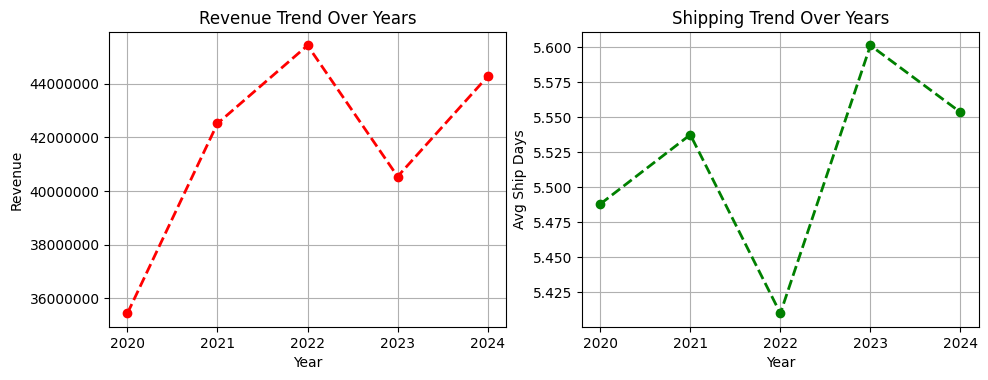

In [12]:
# Revenue Trend and Shipping Analysis:
yearly_revenue = df.groupby("order_year")["sales_amount"].sum()
avg_ship_days = df.groupby("order_year")["days_to_ship"].mean()

plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
plt.plot(yearly_revenue.index,yearly_revenue.values,color='red',marker='o',linewidth=2,linestyle='--')
plt.xticks(yearly_revenue.index)
plt.title("Revenue Trend Over Years")
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid()

plt.subplot(2,2,2)
plt.plot(avg_ship_days.index,avg_ship_days.values,color='green',marker='o',linewidth=2,linestyle='--')
plt.xticks(avg_ship_days.index)
plt.title("Shipping Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Avg Ship Days")
plt.grid()

plt.tight_layout()
plt.show()

## **QUICK INSIGHTS**

### -> The Sales trend over years shows a sharp drop in 2024, but the Revenue is increasing in the same year. That means the avg price per product likely increased.  
### -> Sales are rapidly increasing in Q3 (month 7-9). This seems to be seasonal trend.
### -> The avg shipping days are least in 2022 but then increased and again decreasing in 2024. Various factors affect the shipping days such as transport, high shipping cost for less products etc.

## *Category Analysis:*

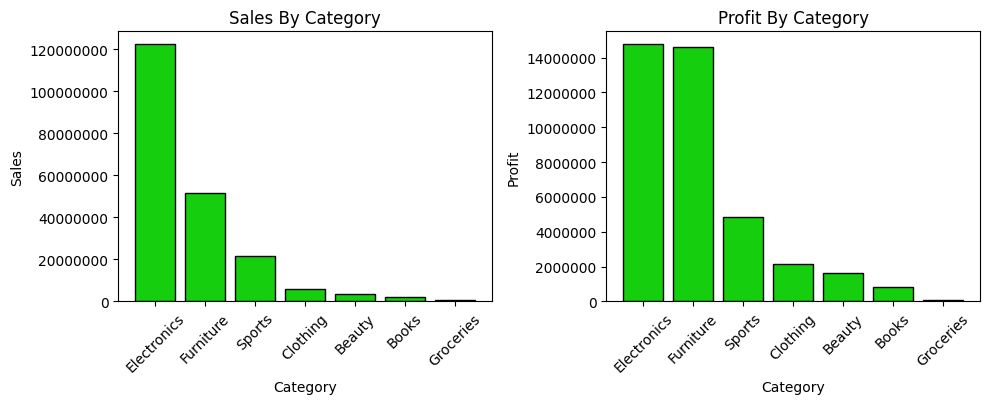

In [22]:
# Category wise sales & profit:

category_sales = df.groupby("product_category")["sales_amount"].sum().sort_values(ascending=False)
category_profit = df.groupby("product_category")["profit"].sum().sort_values(ascending=False).round()

plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
plt.bar(category_sales.index,category_sales.values,color="#15cf0e",edgecolor="black")
plt.title("Sales By Category")
plt.xlabel("Category")
plt.xticks(rotation = 45)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Sales")

plt.subplot(2,2,2)
plt.bar(category_profit.index,category_profit.values,color="#15cf0e",edgecolor="black")
plt.title("Profit By Category")
plt.xlabel("Category")
plt.xticks(rotation = 45)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Profit")


plt.savefig("Category_Analysis.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
category_summary = df.groupby("product_category").agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit", "sum"))
category_summary["profit_margin"] = category_summary["total_profit"] / category_summary["total_sales"]
print(category_summary.sort_values("profit_margin", ascending=False))

                   total_sales  total_profit  profit_margin
product_category                                           
Beauty            3.562580e+06    1611757.80       0.452413
Books             2.106005e+06     839087.71       0.398426
Clothing          6.016584e+06    2119208.27       0.352228
Furniture         5.151305e+07   14585678.09       0.283145
Sports            2.173867e+07    4834893.71       0.222410
Electronics       1.224274e+08   14768532.33       0.120631
Groceries         8.217408e+05      65443.04       0.079640


## **QUICK INSIGHTS**

### -> Electronics dominate both in sales and profit by remaining at the top.
### -> While Electronics generates the highest profit,but if we talk about profit margins, Beauty & Books have higher profit margins.

## *Region/Demographic comparison:*

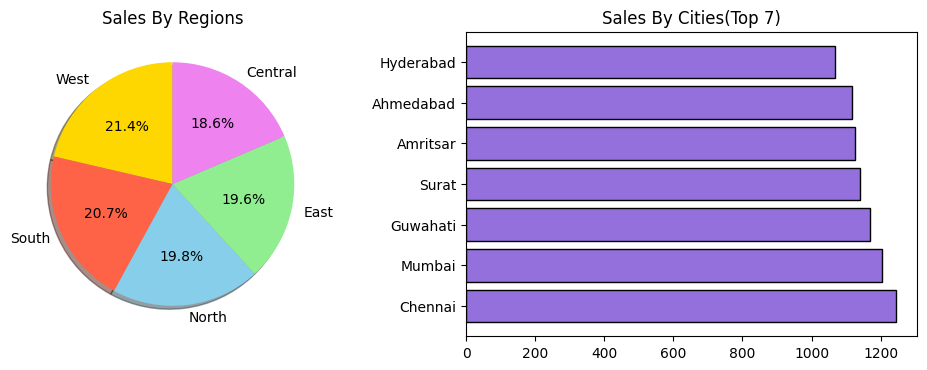

In [15]:
# Sales by region and city:

region_sales = df.groupby("region")["quantity"].sum().sort_values(ascending=False)
city_sales = df.groupby("city")["quantity"].sum().sort_values(ascending=False).head(7)

plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
colors = ['gold', 'tomato', 'skyblue', 'lightgreen', 'violet']
plt.pie(region_sales.values,labels=region_sales.index,autopct='%1.1f%%',shadow=True,startangle=90,colors=colors)
plt.title("Sales By Regions")

plt.subplot(2,2,2)
plt.barh(city_sales.index,city_sales.values,color="mediumpurple",edgecolor="black")
plt.title("Sales By Cities(Top 7)")

plt.tight_layout()
plt.show()

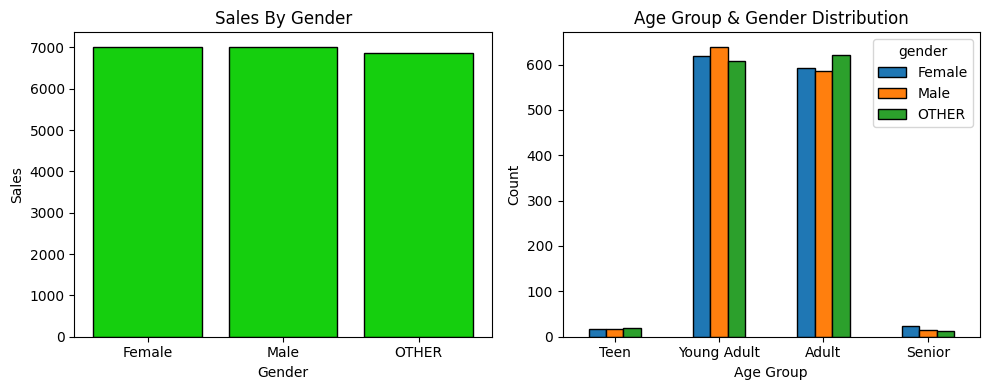

In [16]:
# Gender-wise sales and age group analysis:
sales_gender = df.groupby("gender")["quantity"].sum().sort_values(ascending=False)

bins = [0,12,18,35,60,100]
labels = ["Child","Teen","Young Adult","Adult","Senior"]
df["age_group"] = pd.cut(df["age"],bins=bins,labels=labels,include_lowest=True)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(sales_gender.index,sales_gender.values,color="#15cf0e",edgecolor="black")
plt.title("Sales By Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")

plt.subplot(1,2,2)
ax = plt.gca()
pd.crosstab(df['age_group'],df['gender']).plot(kind='bar',ax=ax,edgecolor="black")
plt.title("Age Group & Gender Distribution")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## **QUICK INSIGHTS**

### -> West region has the highest sales, while South leads in profit.
### -> Chennai city shows strong numbers in sales along with profit contriutions as it leads the chart in top 7 cities.
### -> Female and Male customers have equal sales numbers. Both are equally important to target for more sales.
### -> Age analysis shows our customers are mainly from Young Adult & Adult age group (18-60).

## *Payment & Order Status Analysis:*

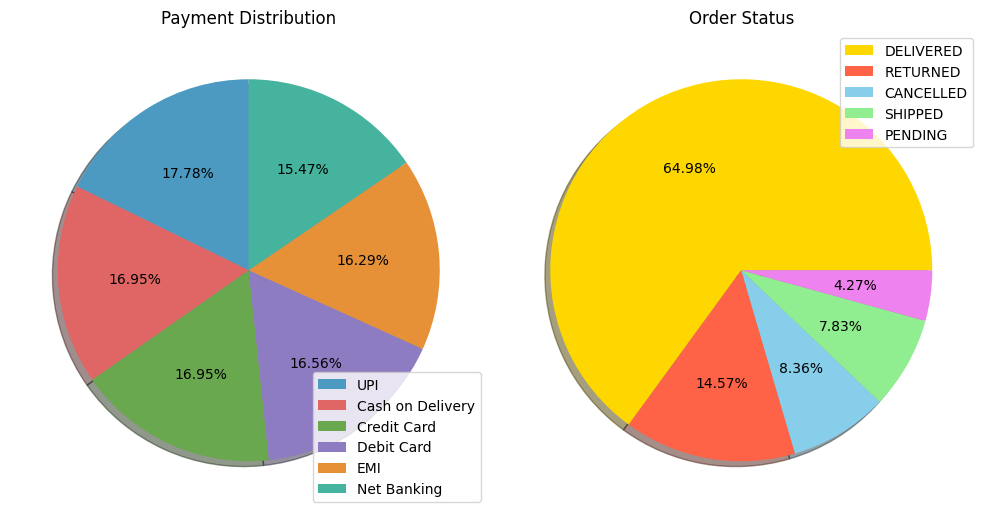

In [23]:
# Payment Method & Order Status Info:

payment_counts =df['payment_method'].value_counts()
order_info = df['order_status'].value_counts()

plt.figure(figsize=(10,7))

plt.subplot(1,2,1)
colors = ['#4C9AC1', '#E06666', '#6AA84F', '#8E7CC3', '#E69138', '#45B39D']
plt.pie(payment_counts.values,autopct='%1.2f%%',startangle=90,shadow=True,colors=colors)
plt.title("Payment Distribution")
plt.legend(labels=payment_counts.index)

plt.subplot(1,2,2)
colors = ['gold', 'tomato', 'skyblue', 'lightgreen', 'violet']
plt.pie(order_info.values,autopct='%1.2f%%',shadow=True,colors=colors)
plt.title("Order Status")
plt.legend(labels=order_info.index)

plt.savefig("Payment_Order_Analysis.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## **QUICK INSIGHTS**

### -> UPI & COD are the most used payment methods.
### -> Around 65% of orders are Delivered but it is noticible that the Returned & Cancelled have also high percentages.

## **📌 IMPORTANT FINDINGS**

In [18]:
# Return Rate by Category:

category_return = df.groupby("product_category")["return_flag"].mean().sort_values(ascending=False)
print(category_return)

product_category
Electronics    0.172542
Groceries      0.156757
Sports         0.154412
Clothing       0.139286
Books          0.136452
Beauty          0.12963
Furniture      0.129344
Name: return_flag, dtype: object


### *-> Electronics has the highest return rate (17.25%) compared to the overall average of 14.57%, while Furniture and Beauty have the lowest (~13%). This is a believable real-world pattern — electronics are commonly returned due to defects or unmet expectations, while bulky items like furniture are less likely to be returned due to the hassle involved. With 500-600+ orders per category, this difference is unlikely to be due to random chance.*

In [19]:
# Customer Spend Concentration: 

# Total spend per customer, sorted highest to lowest
customer_spend = df.groupby("customer_id")["sales_amount"].sum().sort_values(ascending=False)

# How many customers make up the "top 10%"
top10_count = int(len(customer_spend) * 0.10)
top10_customers = customer_spend.head(top10_count)

# What % of total revenue do these top 10% contribute?
top10_revenue_share = top10_customers.sum() / customer_spend.sum() * 100
print(f"Top 10% of customers contribute {top10_revenue_share:.2f}% of total revenue")

# What are these top spenders actually buying? (category breakdown)
top10_orders = df[df["customer_id"].isin(top10_customers.index)]
print(top10_orders["product_category"].value_counts())

# Checking if it's a price effect — avg unit price per category
print(df.groupby("product_category")["unit_price"].mean().sort_values(ascending=False))

Top 10% of customers contribute 60.45% of total revenue
product_category
Electronics    277
Furniture       98
Beauty           4
Clothing         3
Groceries        2
Sports           1
Name: count, dtype: int64
product_category
Electronics    42923.121039
Furniture      18655.480154
Sports          8037.650533
Clothing        2174.354911
Beauty          1315.815500
Books            840.006901
Groceries        284.688054
Name: unit_price, dtype: float64


### *-> Top 10% of customers bring in 60.5% of revenue. This isn't because of loyal repeat buyers (most customers order only once or twice) — it's because they bought pricier items like Electronics and Furniture. Age doesn't play a role.*

## **🏁 Final Verdict**

### - Sales volume dropped in 2024, but revenue rose — average order value increased.
### - Sales peak in Q3 (months 7-9), pointing to a seasonal buying pattern.
### - Electronics leads in both total sales and profit, but Beauty & Books have the highest profit margins.
### - West region leads in sales, while South leads in profit — different regions may need different strategies.
### - Electronics has the highest return rate (17.25%) vs. the 14.57% average, likely due to defects or unmet expectations.
### - Top 10% of customers generate 60.5% of total revenue — driven by high-priced Electronics/Furniture purchases, not repeat loyalty.
### - UPI and COD are the most preferred payment methods, while ~65% of orders are successfully delivered.

## **💡 Business Recommendations**

### - Investigate Electronics' high return rate (17.25%) — check for product defects or unclear listings; reducing returns here would recover the most lost revenue.
### - Focus retention efforts on top 10% customers (60.5% of revenue) with loyalty perks or personalized offers, since the business is highly dependent on them.
### - Since revenue per order is rising while volume drops, consider bundling or upselling lower-priced categories (Groceries, Beauty) to grow volume alongside revenue.
### - Apply South region's strategies (higher profit) to West region (higher sales) to try boosting profit margins there too.
### - Promote Beauty & Books more — they have the best profit margins despite lower sales volume, so there's room to grow them profitably.
### - Push UPI/COD payment options further since they're already preferred — ensure they're frictionless at checkout.

## **THANK YOU** 